# Fingerprint Target Preparation & Analysis

This notebook documents the preparation and verification of fingerprint targets
used for DreaMS fine-tuning experiments. It covers:

1. **ECFP4 / Morgan (2048-bit)** — Baseline fingerprint (reference)
2. **MACCS (166-bit)** — Structural key-based fingerprint
3. **MAP4 (2048-dim)** — MinHash-based topological fingerprint

For each fingerprint type we:
- Generate fingerprints for all molecules in the finetuning dataset
- Report statistics per split (train/val)
- Compare bit density and value distributions

**Dataset:** MassSpecGym finetuning split (Murcko histogram scaffold split)

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import MACCSkeys, AllChem

try:
    from map4 import MAP4
    MAP4_AVAILABLE = True
    print('MAP4 package available')
except ImportError:
    MAP4_AVAILABLE = False
    print('MAP4 package NOT available — MAP4 section will be skipped')

# Path to the finetuning HDF5 dataset
HDF5_PATH = '../data/processed/MassSpecGym_splits/finetuning.hdf5'

# Cache file — fingerprints are saved here after first computation
CACHE_PATH = Path('../data/processed/MassSpecGym_splits/fingerprint_cache.npz')

def load_cache():
    """Load cached fingerprints if available."""
    if CACHE_PATH.exists():
        data = np.load(CACHE_PATH, allow_pickle=False)
        print(f'Loaded fingerprint cache from {CACHE_PATH}')
        print(f'  Cached arrays: {list(data.keys())}')
        return dict(data)
    return {}

def save_cache(**arrays):
    """Save/update fingerprint cache."""
    existing = load_cache() if CACHE_PATH.exists() else {}
    existing.update(arrays)
    np.savez_compressed(CACHE_PATH, **existing)
    print(f'Saved cache ({list(arrays.keys())}) → {CACHE_PATH}')

cache = load_cache()

MAP4 package available
Loaded fingerprint cache from ../data/processed/MassSpecGym_splits/fingerprint_cache.npz
  Cached arrays: ['morgan_fps']


## 1. Load Dataset & Inspect Structure

In [3]:
with h5py.File(HDF5_PATH, 'r') as f:
    print('Datasets:', list(f.keys()))
    for k in f.keys():
        print(f'  {k}: shape={f[k].shape}, dtype={f[k].dtype}')
    
    # Load SMILES and fold assignments
    smiles_raw = f['smiles'][:]
    folds_raw = f['fold'][:]

smiles = np.array([s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in smiles_raw])
folds = np.array([s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in folds_raw])

n_total = len(smiles)
fold_counts = Counter(folds)
print(f'\nTotal molecules: {n_total}')
print(f'Splits: {dict(fold_counts)}')
print(f'Unique SMILES: {len(set(smiles))}')

Datasets: ['adduct', 'fold', 'precursor_mz', 'smiles', 'spectrum']
  adduct: shape=(159271,), dtype=|S7
  fold: shape=(159271,), dtype=|S5
  precursor_mz: shape=(159271,), dtype=float64
  smiles: shape=(159271,), dtype=|S255
  spectrum: shape=(159271, 2, 128), dtype=float32

Total molecules: 159271
Splits: {'train': 135856, 'val': 23415}
Unique SMILES: 21471


## 2. ECFP4 / Morgan Fingerprints (2048-bit) — Reference

Morgan fingerprints with radius 2 are equivalent to ECFP4 (Extended-Connectivity
Fingerprints with diameter 4). These are the baseline fingerprint used in the
original DreaMS fine-tuning experiments.

```python
from rdkit.Chem import AllChem
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
```

In [4]:
def compute_morgan(smiles_str, fp_size=2048, radius=2):
    """Compute Morgan/ECFP4 fingerprint from SMILES."""
    mol = Chem.MolFromSmiles(smiles_str)
    if mol is None:
        return np.zeros(fp_size, dtype=np.uint8)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=fp_size)
    return np.array(fp, dtype=np.uint8)

if 'morgan_fps' in cache:
    morgan_fps = cache['morgan_fps']
    print(f'Loaded Morgan/ECFP4 from cache: {morgan_fps.shape}')
else:
    morgan_fps = np.zeros((n_total, 2048), dtype=np.uint8)
    morgan_failed = 0

    for i, s in enumerate(tqdm(smiles, desc='Computing Morgan/ECFP4')):
        fp = compute_morgan(s)
        if fp.sum() == 0 and s != '':
            morgan_failed += 1
        morgan_fps[i] = fp

    print(f'\nComputed: {n_total - morgan_failed}/{n_total} (failed: {morgan_failed})')
    save_cache(morgan_fps=morgan_fps)

print(f'Shape: {morgan_fps.shape}, dtype: {morgan_fps.dtype}')

Loaded Morgan/ECFP4 from cache: (159271, 2048)
Shape: (159271, 2048), dtype: uint8


In [5]:
def report_binary_fp_stats(fps, folds, name='Fingerprint'):
    """Report density statistics for binary fingerprints."""
    n_bits = fps.shape[1]
    bits_per_mol = fps.sum(axis=1)
    density = fps.mean()
    
    print(f'=== {name} ({n_bits}-bit) ===')
    print(f'Overall bit density: {density:.4f} ({density*100:.2f}%)')
    print(f'Avg bits set per molecule: {bits_per_mol.mean():.1f} / {n_bits}')
    print(f'Bits set range: [{bits_per_mol.min()}, {bits_per_mol.max()}]')
    print()
    
    rows = []
    for fold_name in sorted(set(folds)):
        mask = folds == fold_name
        subset = fps[mask]
        d = subset.mean()
        avg_bits = subset.sum(axis=1).mean()
        rows.append({
            'Split': fold_name,
            'N': int(mask.sum()),
            'Bit Density': f'{d:.4f} ({d*100:.2f}%)',
            'Avg Bits Set': f'{avg_bits:.1f}',
            'Min Bits': int(subset.sum(axis=1).min()),
            'Max Bits': int(subset.sum(axis=1).max()),
        })
    return pd.DataFrame(rows)

morgan_stats = report_binary_fp_stats(morgan_fps, folds, 'Morgan/ECFP4')
morgan_stats

=== Morgan/ECFP4 (2048-bit) ===
Overall bit density: 0.0223 (2.23%)
Avg bits set per molecule: 45.8 / 2048
Bits set range: [4, 108]



,Split,N,Bit Density,Avg Bits Set,Min Bits,Max Bits
0,train,135856,0.0224 (2.24%),45.8,4,108
1,val,23415,0.0222 (2.22%),45.5,6,103


## 3. MACCS Keys (166-bit)

MACCS (Molecular ACCess System) keys are a set of 166 predefined structural
fragment keys. Each bit corresponds to the presence/absence of a specific
substructure pattern.

Key differences from Morgan/ECFP4:
- **Fixed, interpretable keys** (each bit has a known chemical meaning)
- **Much higher bit density** (~20-30% vs ~2% for ECFP4)
- **Smaller vector** (166 vs 2048 bits)

```python
from rdkit.Chem import MACCSkeys
fp = MACCSkeys.GenMACCSKeys(mol)  # 167 bits, bit 0 unused
arr = np.array(fp)[1:]            # → 166 bits
```

### Architecture change for MACCS
The only change in the DreaMS architecture is the output dimension of the
prediction head: `rho(1024 → 166)` instead of `rho(1024 → 2048)` for Morgan.

In [6]:
def compute_maccs(smiles_str):
    """Compute MACCS 166-bit fingerprint from SMILES.
    
    RDKit's GenMACCSKeys returns 167 bits (indices 0-166).
    Bit 0 is unused, so we drop it → 166 bits.
    """
    mol = Chem.MolFromSmiles(smiles_str)
    if mol is None:
        return np.zeros(166, dtype=np.uint8)
    fp = MACCSkeys.GenMACCSKeys(mol)
    return np.array(fp, dtype=np.uint8)[1:]  # Drop bit 0

if 'maccs_fps' in cache:
    maccs_fps = cache['maccs_fps']
    print(f'Loaded MACCS from cache: {maccs_fps.shape}')
else:
    maccs_fps = np.zeros((n_total, 166), dtype=np.uint8)
    maccs_failed = 0

    for i, s in enumerate(tqdm(smiles, desc='Computing MACCS')):
        fp = compute_maccs(s)
        if fp.sum() == 0 and s != '':
            maccs_failed += 1
        maccs_fps[i] = fp

    print(f'\nComputed: {n_total - maccs_failed}/{n_total} (failed: {maccs_failed})')
    save_cache(maccs_fps=maccs_fps)

print(f'Shape: {maccs_fps.shape}, dtype: {maccs_fps.dtype}')

Computing MACCS: 100%|██████████| 159271/159271 [03:47<00:00, 701.57it/s] 



Computed: 159271/159271 (failed: 0)
Loaded fingerprint cache from ../data/processed/MassSpecGym_splits/fingerprint_cache.npz
  Cached arrays: ['morgan_fps']
Saved cache (['maccs_fps']) → ../data/processed/MassSpecGym_splits/fingerprint_cache.npz
Shape: (159271, 166), dtype: uint8


In [7]:
maccs_stats = report_binary_fp_stats(maccs_fps, folds, 'MACCS')
maccs_stats

=== MACCS (166-bit) ===
Overall bit density: 0.2648 (26.48%)
Avg bits set per molecule: 44.0 / 166
Bits set range: [5, 106]



,Split,N,Bit Density,Avg Bits Set,Min Bits,Max Bits
0,train,135856,0.2651 (26.51%),44.0,5,106
1,val,23415,0.2633 (26.33%),43.7,8,91


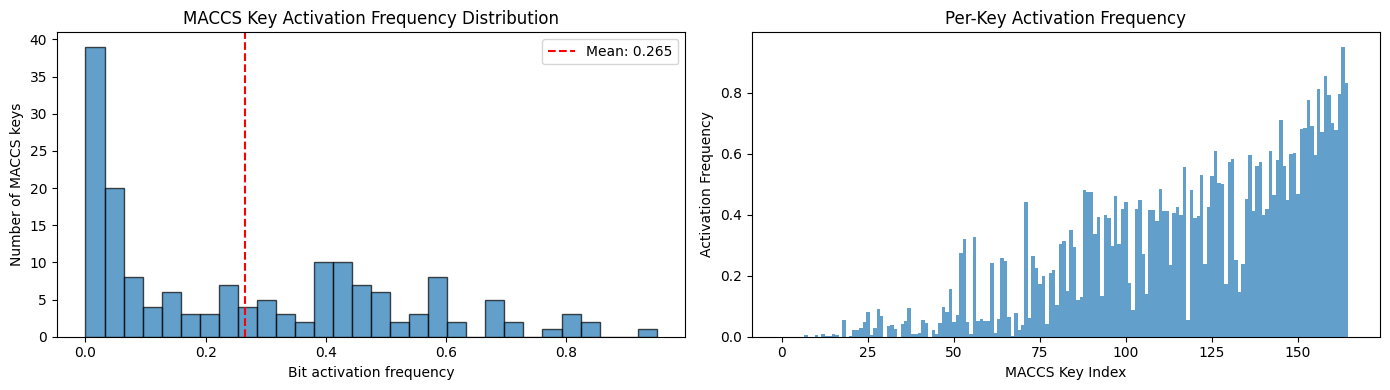

Top 10 most active MACCS keys:
  Key 164: 0.9510 (95.1%)
  Key 159: 0.8557 (85.6%)
  Key 165: 0.8339 (83.4%)
  Key 157: 0.8123 (81.2%)
  Key 163: 0.7976 (79.8%)
  Key 160: 0.7945 (79.4%)
  Key 154: 0.7749 (77.5%)
  Key 146: 0.7123 (71.2%)
  Key 161: 0.7014 (70.1%)
  Key 155: 0.6909 (69.1%)

Top 10 least active MACCS keys (excl. always-off):
  Key   1: 0.0000 (0.0%)
  Key  35: 0.0000 (0.0%)
  Key  12: 0.0000 (0.0%)
  Key  10: 0.0000 (0.0%)
  Key   9: 0.0000 (0.0%)
  Key   7: 0.0000 (0.0%)
  Key 166: 0.0000 (0.0%)
  Key   6: 0.0000 (0.0%)
  Key   5: 0.0000 (0.0%)
  Key   4: 0.0000 (0.0%)


In [8]:
# Per-bit activation frequency for MACCS (which keys are most/least common?)
maccs_bit_freq = maccs_fps.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of bit frequencies
axes[0].hist(maccs_bit_freq, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Bit activation frequency')
axes[0].set_ylabel('Number of MACCS keys')
axes[0].set_title('MACCS Key Activation Frequency Distribution')
axes[0].axvline(maccs_bit_freq.mean(), color='red', linestyle='--', label=f'Mean: {maccs_bit_freq.mean():.3f}')
axes[0].legend()

# Bar chart of all 166 bits
axes[1].bar(range(166), maccs_bit_freq, width=1.0, alpha=0.7)
axes[1].set_xlabel('MACCS Key Index')
axes[1].set_ylabel('Activation Frequency')
axes[1].set_title('Per-Key Activation Frequency')

plt.tight_layout()
plt.show()

# Most and least common keys
top_10 = np.argsort(maccs_bit_freq)[::-1][:10]
bottom_10 = np.argsort(maccs_bit_freq)[:10]
print('Top 10 most active MACCS keys:')
for idx in top_10:
    print(f'  Key {idx+1:3d}: {maccs_bit_freq[idx]:.4f} ({maccs_bit_freq[idx]*100:.1f}%)')
print('\nTop 10 least active MACCS keys (excl. always-off):')
for idx in bottom_10:
    print(f'  Key {idx+1:3d}: {maccs_bit_freq[idx]:.4f} ({maccs_bit_freq[idx]*100:.1f}%)')

## 4. MAP4 Fingerprints (2048-dim)

MAP4 (MinHashed Atom-Pair fingerprint of radius 2) is a topological fingerprint
that encodes circular substructures via MinHashing. Unlike Morgan/MACCS, MAP4
produces **integer values** (MinHash signatures), not binary bits.

```python
from map4 import MAP4
calc = MAP4(dimensions=2048, radius=2)
fp = calc.calculate(mol)  # Returns integer array
```

### Key properties
- **Output type:** Integer (MinHash values), not binary
- **Dimensions:** 2048 (configurable)
- **Loss function:** Cosine similarity loss works well since it measures
  directional agreement regardless of magnitude
- **Architecture:** Same head dimension as Morgan: `rho(1024 → 2048)`

In [12]:
if MAP4_AVAILABLE:
    if 'map4_fps' in cache:
        map4_fps = cache['map4_fps']
        print(f'Loaded MAP4 from cache: {map4_fps.shape}')
    else:
        map4_calc = MAP4(dimensions=2048, radius=2)

        def compute_map4(smiles_str):
            """Compute MAP4 2048-dim fingerprint from SMILES."""
            mol = Chem.MolFromSmiles(smiles_str)
            if mol is None:
                return np.zeros(2048, dtype=np.float32)
            try:
                fp = map4_calc.calculate(mol)
                return np.asarray(fp, dtype=np.float32)
            except Exception as e:
                print(f'  Warning: MAP4 failed for {smiles_str}: {e}')
                return np.zeros(2048, dtype=np.float32)

        map4_fps = np.zeros((n_total, 2048), dtype=np.float32)
        map4_failed = 0

        for i, s in enumerate(tqdm(smiles, desc='Computing MAP4')):
            fp = compute_map4(s)
            if fp.sum() == 0 and s != '':
                map4_failed += 1
            map4_fps[i] = fp

        print(f'\nComputed: {n_total - map4_failed}/{n_total} (failed: {map4_failed})')
        save_cache(map4_fps=map4_fps)

    print(f'Shape: {map4_fps.shape}, dtype: {map4_fps.dtype}')
else:
    print('Skipping MAP4 computation — package not available.')
    print('Install with: pip install map4')

Computing MAP4: 100%|██████████| 159271/159271 [06:40<00:00, 397.49it/s]



Computed: 159271/159271 (failed: 0)
Loaded fingerprint cache from ../data/processed/MassSpecGym_splits/fingerprint_cache.npz
  Cached arrays: ['morgan_fps', 'maccs_fps']
Saved cache (['map4_fps']) → ../data/processed/MassSpecGym_splits/fingerprint_cache.npz
Shape: (159271, 2048), dtype: float32


In [13]:
if MAP4_AVAILABLE:
    # MAP4 value distribution analysis
    print('=== MAP4 (2048-dim) ===')
    print(f'Value type: {map4_fps.dtype}')
    print(f'Value range: [{map4_fps.min():.1f}, {map4_fps.max():.1f}]')
    print(f'Mean value: {map4_fps.mean():.4f}')
    print(f'Std value: {map4_fps.std():.4f}')
    
    # Check if values are binary
    unique_vals = np.unique(map4_fps)
    is_binary = set(unique_vals).issubset({0.0, 1.0})
    print(f'\nBinary fingerprint: {is_binary}')
    print(f'Unique values: {len(unique_vals)} (showing first 20: {unique_vals[:20]})')
    
    # Non-zero fraction
    nonzero_frac = (map4_fps != 0).mean()
    print(f'\nNon-zero fraction: {nonzero_frac:.4f} ({nonzero_frac*100:.2f}%)')
    
    # Per-split statistics
    print()
    rows = []
    for fold_name in sorted(set(folds)):
        mask = folds == fold_name
        subset = map4_fps[mask]
        nz = (subset != 0).mean()
        rows.append({
            'Split': fold_name,
            'N': int(mask.sum()),
            'Non-zero frac': f'{nz:.4f} ({nz*100:.2f}%)',
            'Mean': f'{subset.mean():.2f}',
            'Std': f'{subset.std():.2f}',
            'Min': f'{subset.min():.1f}',
            'Max': f'{subset.max():.1f}',
        })
    display(pd.DataFrame(rows))

=== MAP4 (2048-dim) ===
Value type: float32
Value range: [0.0, 1.0]
Mean value: 0.2673
Std value: 0.4426

Binary fingerprint: True
Unique values: 2 (showing first 20: [0. 1.])

Non-zero fraction: 0.2674 (26.74%)



,Split,N,Non-zero frac,Mean,Std,Min,Max
0,train,135856,0.2672 (26.72%),0.27,0.44,0.0,1.0
1,val,23415,0.2680 (26.80%),0.27,0.44,0.0,1.0


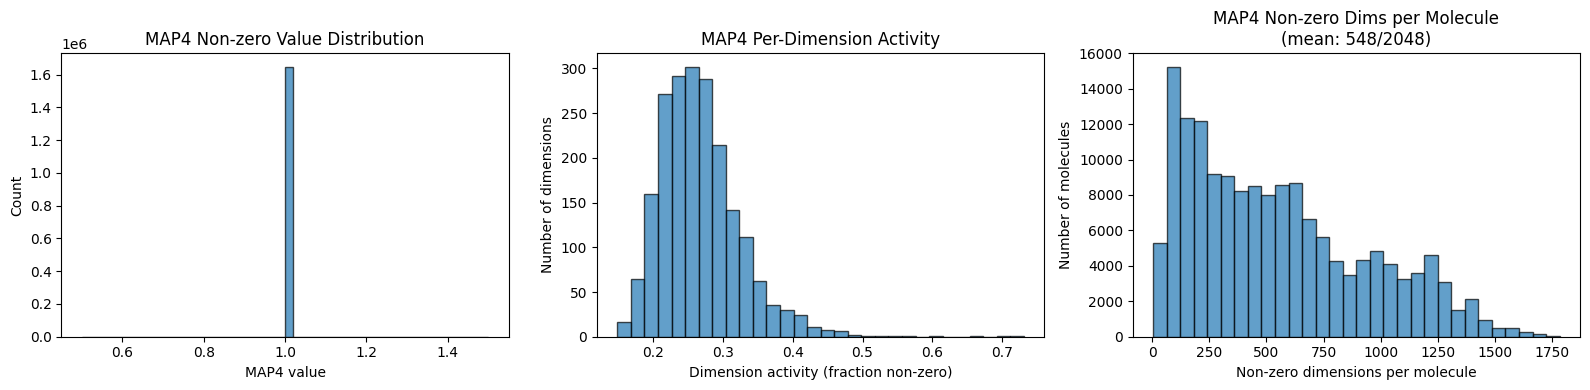

In [14]:
if MAP4_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Value distribution (sample for speed)
    sample_vals = map4_fps[:5000].flatten()
    nonzero_vals = sample_vals[sample_vals != 0]
    
    axes[0].hist(nonzero_vals, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('MAP4 value')
    axes[0].set_ylabel('Count')
    axes[0].set_title('MAP4 Non-zero Value Distribution')
    
    # Per-dimension activity
    dim_activity = (map4_fps != 0).mean(axis=0)
    axes[1].hist(dim_activity, bins=30, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Dimension activity (fraction non-zero)')
    axes[1].set_ylabel('Number of dimensions')
    axes[1].set_title('MAP4 Per-Dimension Activity')
    
    # Bits/values set per molecule
    vals_per_mol = (map4_fps != 0).sum(axis=1)
    axes[2].hist(vals_per_mol, bins=30, edgecolor='black', alpha=0.7)
    axes[2].set_xlabel('Non-zero dimensions per molecule')
    axes[2].set_ylabel('Number of molecules')
    axes[2].set_title(f'MAP4 Non-zero Dims per Molecule\n(mean: {vals_per_mol.mean():.0f}/2048)')
    
    plt.tight_layout()
    plt.show()

## 5. Comparison Summary

Side-by-side comparison of all three fingerprint types.

In [15]:
# Summary comparison table
morgan_density = morgan_fps.mean()
maccs_density = maccs_fps.mean()
morgan_bits_avg = morgan_fps.sum(axis=1).mean()
maccs_bits_avg = maccs_fps.sum(axis=1).mean()

comparison = [
    {
        'Fingerprint': 'Morgan/ECFP4',
        'Dimensions': 2048,
        'Type': 'Binary',
        'Bit/Value Density': f'{morgan_density:.4f} ({morgan_density*100:.2f}%)',
        'Avg Active per Mol': f'{morgan_bits_avg:.1f}',
        'Loss Function': 'Cosine / BCE',
        'Head Output': 'rho(1024→2048)',
    },
    {
        'Fingerprint': 'MACCS',
        'Dimensions': 166,
        'Type': 'Binary',
        'Bit/Value Density': f'{maccs_density:.4f} ({maccs_density*100:.2f}%)',
        'Avg Active per Mol': f'{maccs_bits_avg:.1f}',
        'Loss Function': 'Cosine / BCE',
        'Head Output': 'rho(1024→166)',
    },
]

if MAP4_AVAILABLE:
    map4_nz = (map4_fps != 0).mean()
    map4_nz_avg = (map4_fps != 0).sum(axis=1).mean()
    comparison.append({
        'Fingerprint': 'MAP4',
        'Dimensions': 2048,
        'Type': 'Integer (MinHash)',
        'Bit/Value Density': f'{map4_nz:.4f} ({map4_nz*100:.2f}%)',
        'Avg Active per Mol': f'{map4_nz_avg:.1f}',
        'Loss Function': 'Cosine / BCE',
        'Head Output': 'rho(1024→2048)',
    })

summary_df = pd.DataFrame(comparison)
summary_df

,Fingerprint,Dimensions,Type,Bit/Value Density,Avg Active per Mol,Loss Function,Head Output
0,Morgan/ECFP4,2048,Binary,0.0223 (2.23%),45.8,Cosine / BCE,rho(1024→2048)
1,MACCS,166,Binary,0.2648 (26.48%),44.0,Cosine / BCE,rho(1024→166)
2,MAP4,2048,Integer (MinHash),0.2674 (26.74%),547.5,Cosine / BCE,rho(1024→2048)


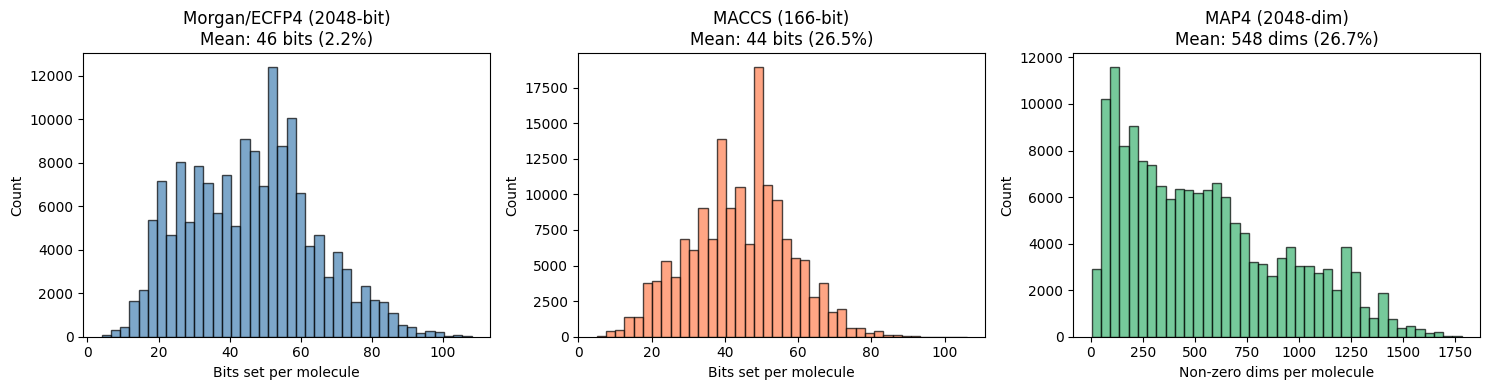

In [16]:
# Visual comparison of bit density distributions
fig, axes = plt.subplots(1, 3 if MAP4_AVAILABLE else 2, figsize=(5 * (3 if MAP4_AVAILABLE else 2), 4))

# Morgan bits per molecule
morgan_bits = morgan_fps.sum(axis=1)
axes[0].hist(morgan_bits, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Bits set per molecule')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Morgan/ECFP4 (2048-bit)\nMean: {morgan_bits.mean():.0f} bits ({morgan_density*100:.1f}%)')

# MACCS bits per molecule
maccs_bits = maccs_fps.sum(axis=1)
axes[1].hist(maccs_bits, bins=40, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Bits set per molecule')
axes[1].set_ylabel('Count')
axes[1].set_title(f'MACCS (166-bit)\nMean: {maccs_bits.mean():.0f} bits ({maccs_density*100:.1f}%)')

# MAP4 non-zero dims per molecule
if MAP4_AVAILABLE:
    map4_nz_per_mol = (map4_fps != 0).sum(axis=1)
    axes[2].hist(map4_nz_per_mol, bins=40, edgecolor='black', alpha=0.7, color='mediumseagreen')
    axes[2].set_xlabel('Non-zero dims per molecule')
    axes[2].set_ylabel('Count')
    axes[2].set_title(f'MAP4 (2048-dim)\nMean: {map4_nz_per_mol.mean():.0f} dims ({map4_nz*100:.1f}%)')

plt.tight_layout()
plt.show()

## 6. Save Precomputed Fingerprints to HDF5

Save computed fingerprints back to the HDF5 file for inspection and reproducibility.
Note: the DreaMS training pipeline computes fingerprints on-the-fly from SMILES,
so these stored columns are for verification and analysis purposes.

In [17]:
SAVE_TO_HDF5 = False  # Set to True to write fingerprints into the HDF5 file

if SAVE_TO_HDF5:
    with h5py.File(HDF5_PATH, 'a') as f:
        # Save Morgan
        if 'fp_morgan_2048' not in f:
            f.create_dataset('fp_morgan_2048', data=morgan_fps, dtype=np.uint8,
                             compression='gzip', compression_opts=4)
            print('Saved fp_morgan_2048')
        else:
            print('fp_morgan_2048 already exists')
        
        # Save MACCS
        if 'fp_maccs_166' not in f:
            f.create_dataset('fp_maccs_166', data=maccs_fps, dtype=np.uint8,
                             compression='gzip', compression_opts=4)
            print('Saved fp_maccs_166')
        else:
            print('fp_maccs_166 already exists')
        
        # Save MAP4
        if MAP4_AVAILABLE:
            if 'fp_map4_2048' not in f:
                f.create_dataset('fp_map4_2048', data=map4_fps, dtype=np.float32,
                                 compression='gzip', compression_opts=4)
                print('Saved fp_map4_2048')
            else:
                print('fp_map4_2048 already exists')
        
        print('\nFinal datasets:', list(f.keys()))
else:
    print('Saving disabled. Set SAVE_TO_HDF5 = True in this cell to write to HDF5.')

Saving disabled. Set SAVE_TO_HDF5 = True in this cell to write to HDF5.


## 7. Methods Section Notes

### Fingerprint Generation

| Fingerprint | Library | Function | Output |
|---|---|---|---|
| ECFP4 (Morgan) | RDKit | `AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)` | 2048-bit binary |
| MACCS | RDKit | `MACCSkeys.GenMACCSKeys(mol)` → drop bit 0 | 166-bit binary |
| MAP4 | map4 | `MAP4(dimensions=2048, radius=2).calculate(mol)` | 2048-dim integer (MinHash) |

### Key Observations

- **MACCS** has ~10× higher bit density than ECFP4, which impacts metric interpretation:
  high binary recall/accuracy is expected, but cosine similarity and Jaccard index
  are more meaningful for cross-fingerprint comparison.
- **MAP4** produces integer (not binary) values via MinHash. Cosine similarity loss
  is used for training, same as the baseline.
- All fingerprints are computed **on-the-fly** during DreaMS fine-tuning from SMILES
  via `dreams.utils.mols.fp_func_from_str()`.
- The only architecture change between fingerprint types is the output dimension
  of the prediction head (rho).